In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report


# Load dataset
df = pd.read_csv('diabetes.csv')
print(df.head())
print(df.info())
print(df.describe())

   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0        4.0   
1     

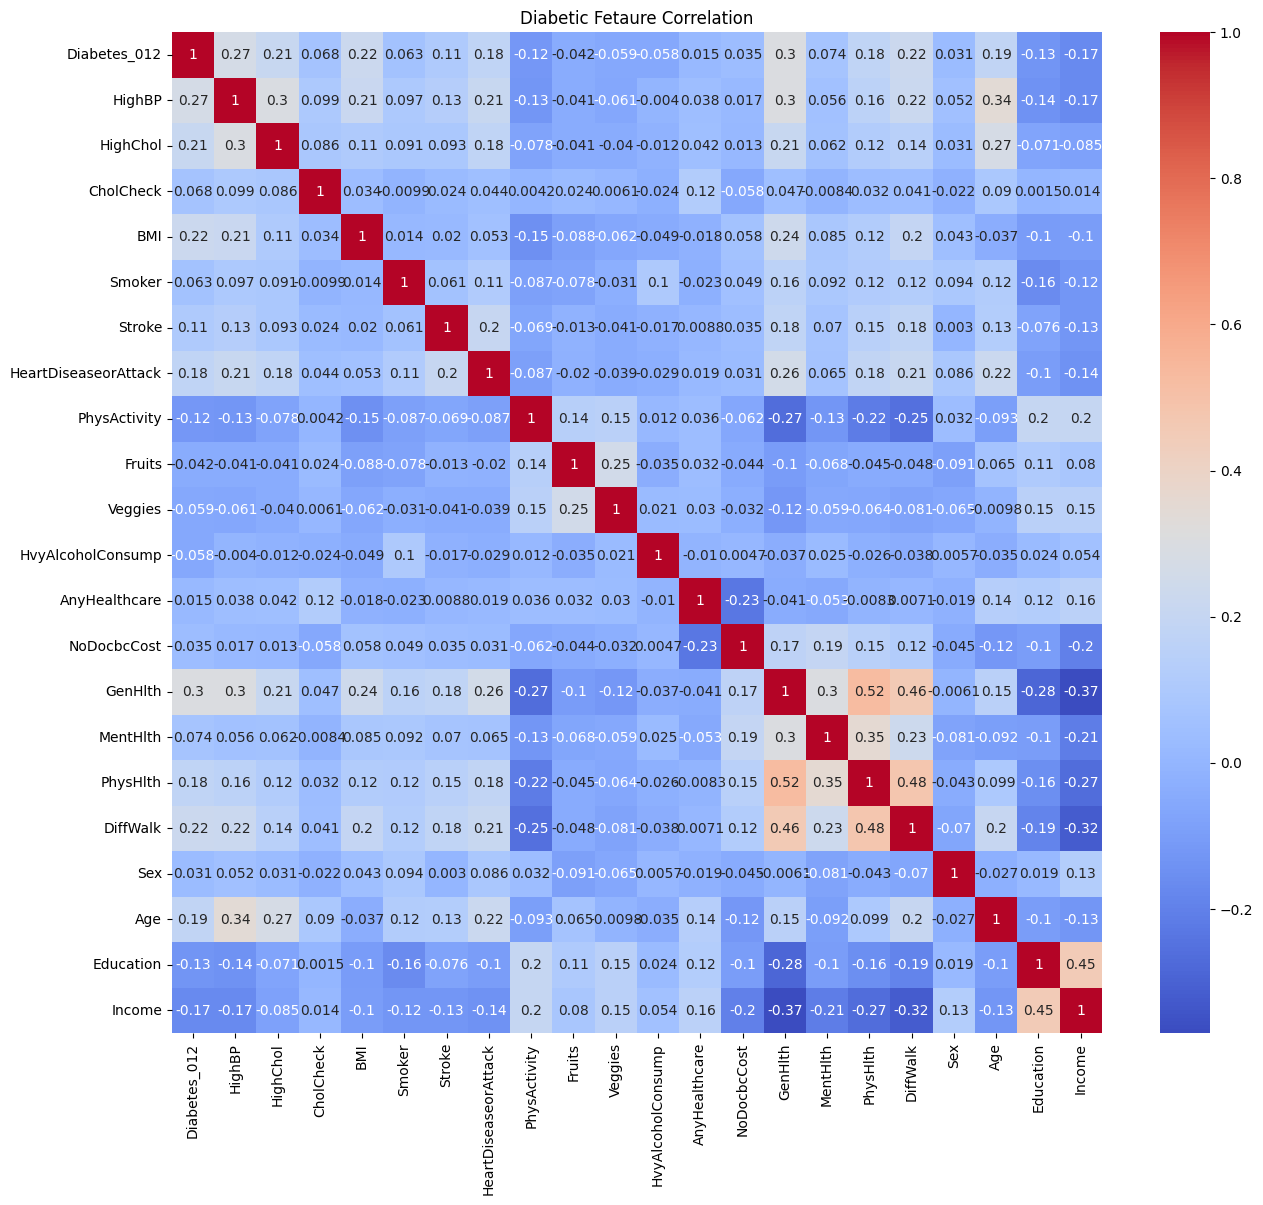

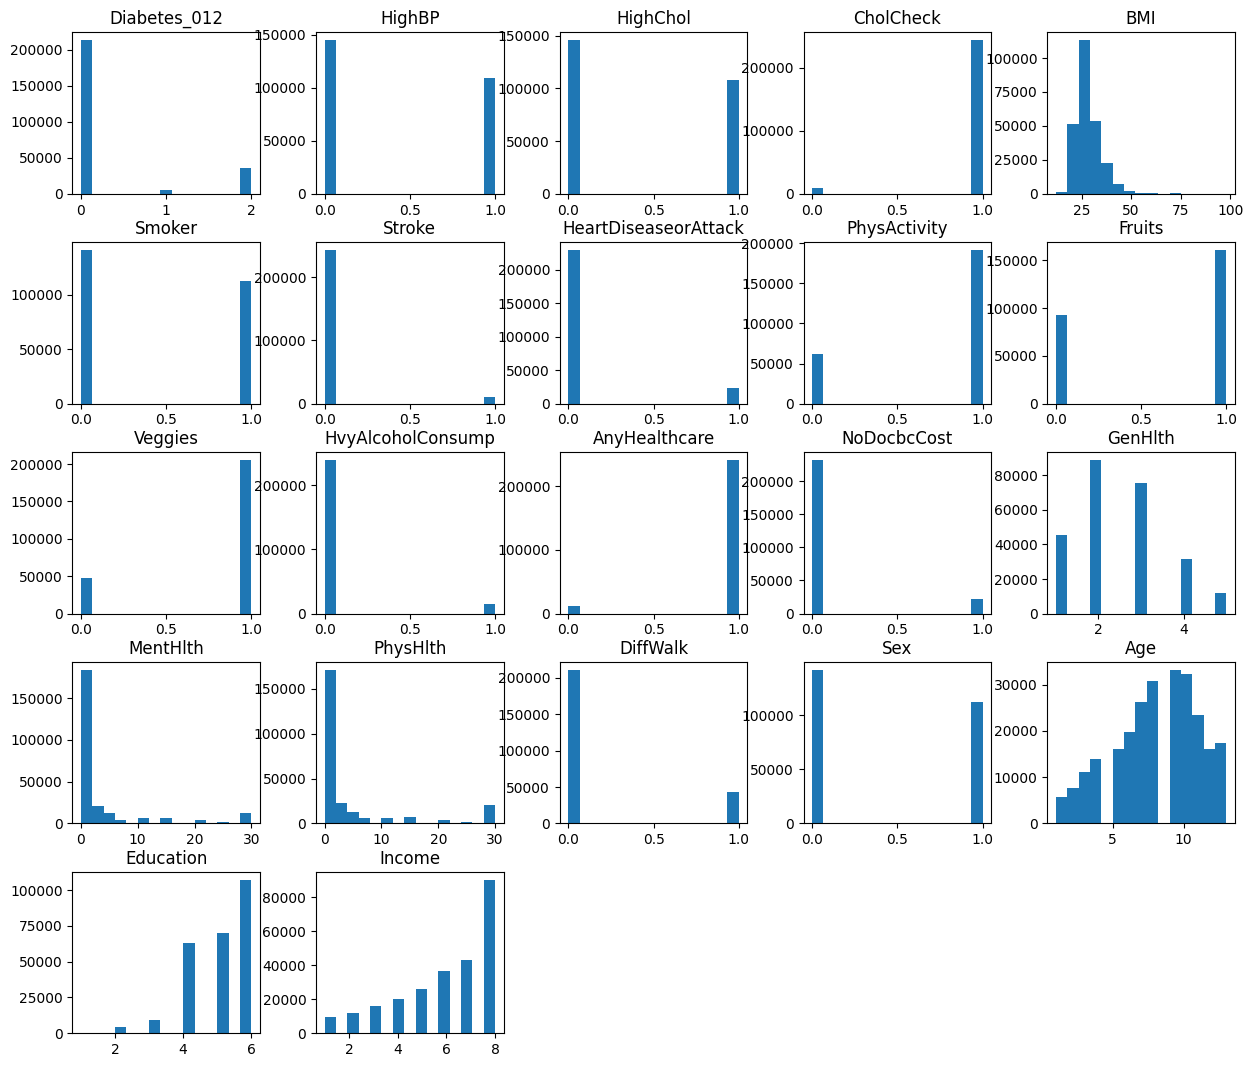

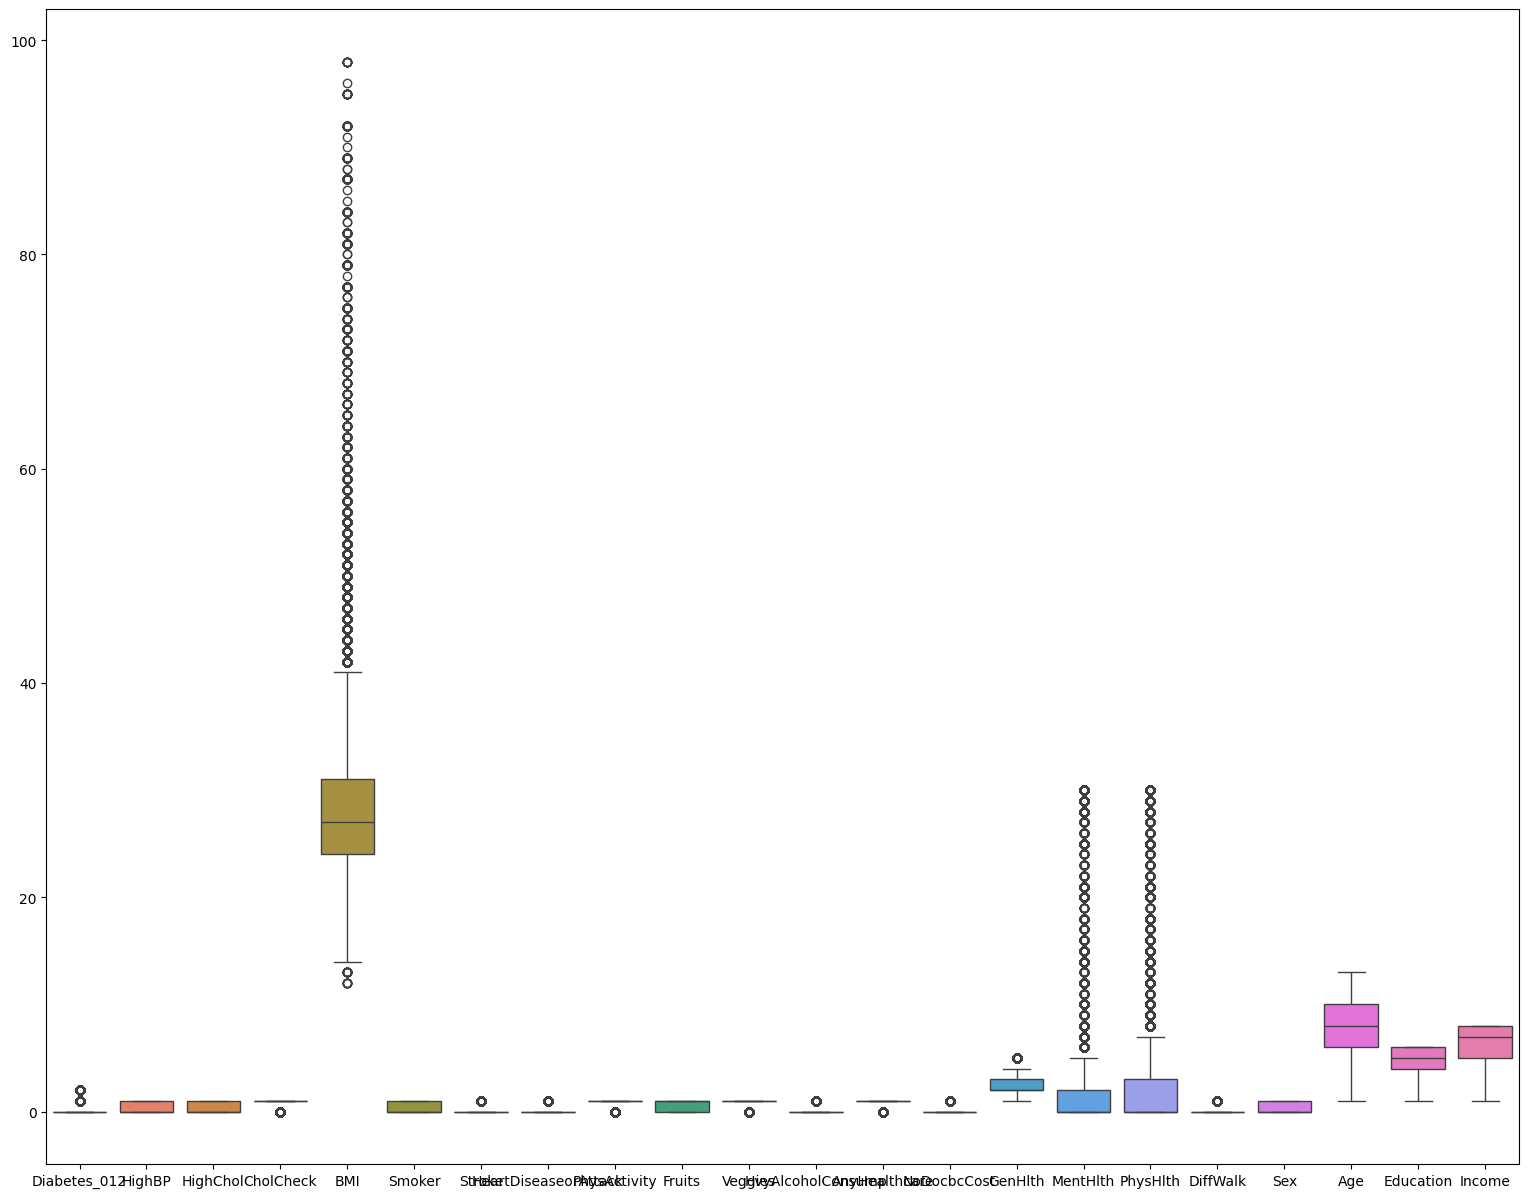

In [8]:
# Visualize
plt.figure(figsize=(15,13))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Diabetic Fetaure Correlation')
plt.show()

df.hist(bins=15, grid=False, figsize=(15,13))
plt.show()

plt.figure(figsize=(19,15))
sns.boxplot(data=df)
plt.show()


In [ ]:
import warnings
warnings.filterwarnings('ignore')
# Split data
x = df.drop(['Diabetes_012'], axis=1)
y = df['Diabetes_012']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Models
models = {
    'Hist Gradient Boosting Classifier': HistGradientBoostingClassifier(random_state=42),
    'Random Forest Classifier': RandomForestClassifier(random_state=42),
    'Cat Boost Classifier': CatBoostClassifier(verbose=0, random_state=42),

}

# Pipeline
for name, method in models.items():
    main_pipeline = Pipeline([
        ('Preprocessing', RobustScaler()),
        ('Models', method)
    ])
    main_pipeline.fit(x_train, y_train)
    predict = main_pipeline.predict(x_test)

    # Evaluate
    print(f'\n{name}')
    print('classification report\n', classification_report(y_test, predict))


Hist Gradient Boosting Classifier
classification report
               precision    recall  f1-score   support

         0.0       0.87      0.98      0.92     42795
         1.0       0.00      0.00      0.00       944
         2.0       0.57      0.19      0.28      6997

    accuracy                           0.85     50736
   macro avg       0.48      0.39      0.40     50736
weighted avg       0.81      0.85      0.81     50736


Random Forest Classifier
classification report
               precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     42795
         1.0       0.00      0.00      0.00       944
         2.0       0.47      0.20      0.28      6997

    accuracy                           0.84     50736
   macro avg       0.44      0.39      0.40     50736
weighted avg       0.79      0.84      0.81     50736


Cat Boost Classifier
classification report
               precision    recall  f1-score   support

         0.0       0.87      0.

In [33]:
# Hyperparameter grids
param_grids = {
    'Random Forest Classifier': {
        'Models__n_estimators': [100, 500, 1000],
        'Models__max_depth': [5, 10, 20],
        'Models__min_samples_split': [2, 5, 10],
    },
    'Hist Gradient Boosting Classifier': {
        'Models__max_iter': [10, 100, 500, 1000],
        'Models__learning_rate': [0.001, 0.01, 0.1],
        'Models__max_depth': [1, 5, 10, 20],
    },
    'Cat Boost Classifier': {
        'Models__iterations': [100, 500, 1000],
        'Models__depth': [4, 6, 8],
        'Models__learning_rate': [0.01, 0.05, 0.1],
    },
}

best_estimators = {}

# Grid Search (Random Forest -> ruang parameter kecil, cocok dicek semua kombinasi)
grid_pipeline = Pipeline([
    ('Preprocessing', RobustScaler()),
    ('Models', models['Random Forest Classifier'])
])
grid_search = GridSearchCV(grid_pipeline, param_grids['Random Forest Classifier'], cv=3, scoring='f1_macro', n_jobs=-1)
grid_search.fit(x_train, y_train)

print('Random Forest Classifier - Grid Search')
print('Best params:', grid_search.best_params_)
print('Best score:', grid_search.best_score_)
best_estimators['Random Forest Classifier'] = grid_search.best_estimator_

# Randomized Search (Hist Gradient Boosting & CatBoost -> ruang parameter besar, cukup sampling)
for name in ['Hist Gradient Boosting Classifier', 'Cat Boost Classifier']:
    random_pipeline = Pipeline([
        ('Preprocessing', RobustScaler()),
        ('Models', models[name])
    ])
    random_search = RandomizedSearchCV(random_pipeline, param_grids[name], n_iter=10, cv=3, scoring='f1_macro', n_jobs=-1, random_state=42)
    random_search.fit(x_train, y_train)

    print(f'\n{name} - Randomized Search')
    print('Best params:', random_search.best_params_)
    print('Best score:', random_search.best_score_)
    best_estimators[name] = random_search.best_estimator_


Random Forest Classifier - Grid Search
Best params: {'Models__max_depth': 20, 'Models__min_samples_split': 2, 'Models__n_estimators': 100}
Best score: 0.3920726387879745

Hist Gradient Boosting Classifier - Randomized Search
Best params: {'Models__max_iter': 100, 'Models__max_depth': 5, 'Models__learning_rate': 0.1}
Best score: 0.39805143974519286

Cat Boost Classifier - Randomized Search
Best params: {'Models__learning_rate': 0.1, 'Models__iterations': 1000, 'Models__depth': 4}
Best score: 0.40080018389855393


In [34]:
# Models with hyperparameter tuning
modelss = {
    'Random Forest Classifier': RandomForestClassifier(random_state=42,max_depth=20, min_samples_split=2, n_estimators=100),
    'Hist Gradient Boosting Classifier': HistGradientBoostingClassifier(max_depth=5, max_iter=100, learning_rate=0.1,random_state=42),
    'Cat Boost Classifier': CatBoostClassifier(verbose=0, random_state=42, learning_rate=0.1, iterations=1000, depth=4),
}

# Pipeline
for name, method in modelss.items():
    main_pipeline = Pipeline([
        ('Preprocessing', RobustScaler()),
        ('Models', method)
    ])
    main_pipeline.fit(x_train, y_train)
    predictt = main_pipeline.predict(x_test)

    # Evaluate
    print(f'\n{name}')
    print('classification report\n', classification_report(y_test, predictt))


Random Forest Classifier
classification report
               precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     42795
         1.0       0.00      0.00      0.00       944
         2.0       0.55      0.18      0.27      6997

    accuracy                           0.85     50736
   macro avg       0.47      0.39      0.40     50736
weighted avg       0.80      0.85      0.81     50736


Hist Gradient Boosting Classifier
classification report
               precision    recall  f1-score   support

         0.0       0.87      0.98      0.92     42795
         1.0       0.00      0.00      0.00       944
         2.0       0.56      0.19      0.28      6997

    accuracy                           0.85     50736
   macro avg       0.48      0.39      0.40     50736
weighted avg       0.81      0.85      0.81     50736


Cat Boost Classifier
classification report
               precision    recall  f1-score   support

         0.0       0.87      0.